<a href="https://colab.research.google.com/github/gulshan0201/DL/blob/main/DL_SA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, GRU, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# STEP 1: LOAD DATA
df = pd.read_csv('tweets.csv')

# -------------------------------
# STEP 2: CLEANING
# -------------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['cleaned_text'] = df['text'].apply(clean_text)

# -------------------------------
# STEP 3: LABEL ENCODING
# -------------------------------
le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])

# -------------------------------
# STEP 4: TOKENIZATION
# -------------------------------
max_features = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=max_len)



Training CNN-LSTM...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.6614 - loss: 0.7758 - val_accuracy: 0.7261 - val_loss: 0.6709
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.8036 - loss: 0.5009 - val_accuracy: 0.7978 - val_loss: 0.5055
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.8729 - loss: 0.3431 - val_accuracy: 0.8029 - val_loss: 0.5372
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.9131 - loss: 0.2440 - val_accuracy: 0.7961 - val_loss: 0.5968

Training CNN-GRU...
Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.6847 - loss: 0.7382 - val_accuracy: 0.7790 - val_loss: 0.5847
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.8170 - loss: 0.4741 - val_accuracy: 0.8003 - val_loss: 0.5042
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.8778 - loss: 0.3236 - val_accuracy: 0.7858 - val_loss: 0.5446
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9182 - loss:

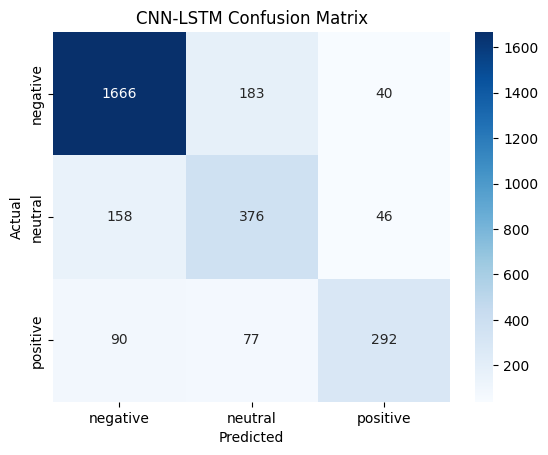

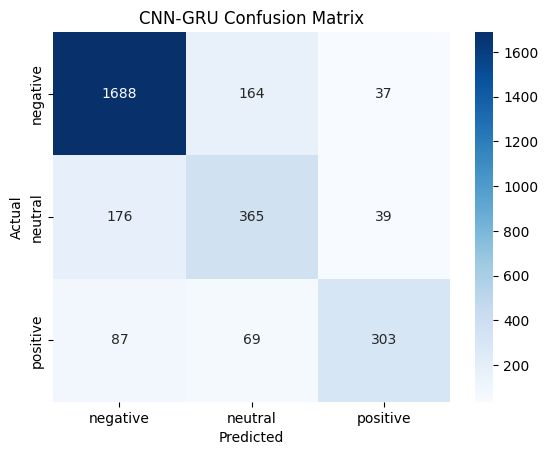

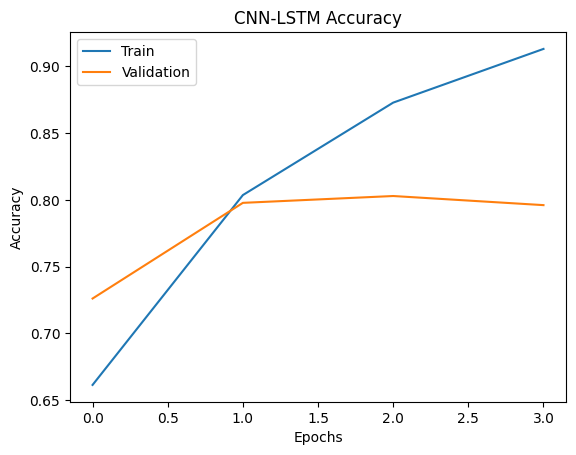

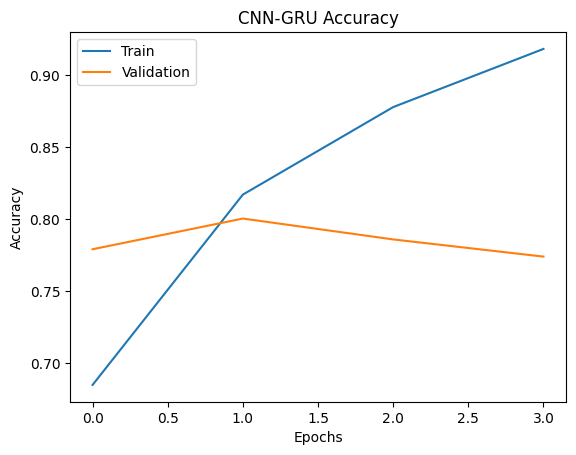

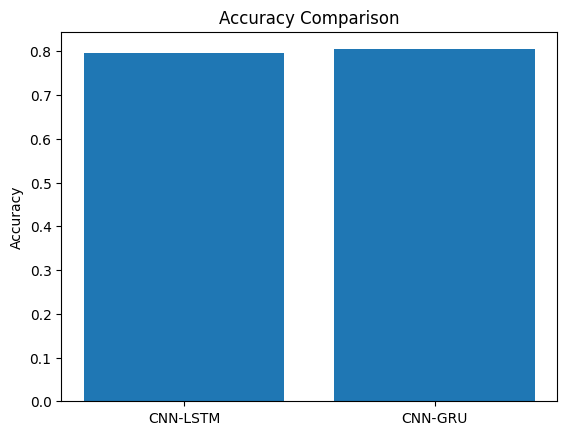

CNN-LSTM Parameters: 1354243
CNN-GRU Parameters: 1346179

FINAL COMPARISON
LSTM Accuracy: 0.7971, Time: 60.81s
GRU Accuracy: 0.8046, Time: 72.63s


In [4]:
# -------------------------------
# STEP 5: TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# STEP 6: MODEL FUNCTION
# -------------------------------
def build_model(model_type='LSTM'):
    model = Sequential([
        Embedding(max_features, 128, input_length=max_len),
        SpatialDropout1D(0.2),
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(pool_size=4),

        LSTM(64, dropout=0.2, recurrent_dropout=0.2)
        if model_type == 'LSTM'
        else GRU(64, dropout=0.2, recurrent_dropout=0.2),

        Dense(3, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# -------------------------------
# STEP 7: CALLBACK
# -------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# -------------------------------
# STEP 8: TRAIN CNN-LSTM
# -------------------------------
print("Training CNN-LSTM...")
cnn_lstm = build_model('LSTM')

start = time.time()
history_lstm = cnn_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
lstm_time = time.time() - start

# -------------------------------
# STEP 9: TRAIN CNN-GRU
# -------------------------------
print("\nTraining CNN-GRU...")
cnn_gru = build_model('GRU')

start = time.time()
history_gru = cnn_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
gru_time = time.time() - start

# -------------------------------
# STEP 10: EVALUATION
# -------------------------------
def evaluate(model, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    return acc, y_pred

acc_lstm, y_pred_lstm = evaluate(cnn_lstm, "CNN-LSTM")
acc_gru, y_pred_gru = evaluate(cnn_gru, "CNN-GRU")

# -------------------------------
# STEP 11: CONFUSION MATRIX
# -------------------------------
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_lstm, "CNN-LSTM Confusion Matrix")
plot_cm(y_test, y_pred_gru, "CNN-GRU Confusion Matrix")

# -------------------------------
# STEP 12: LEARNING CURVES
# -------------------------------
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_lstm, "CNN-LSTM Accuracy")
plot_history(history_gru, "CNN-GRU Accuracy")

# -------------------------------
# STEP 13: COMPARISON
# -------------------------------
plt.bar(['CNN-LSTM', 'CNN-GRU'], [acc_lstm, acc_gru])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# -------------------------------
# STEP 14: COMPLEXITY (FIXED)
# -------------------------------
def model_complexity(model, name):
    params = model.count_params()
    print(f"{name} Parameters: {params}")
    return params

params_lstm = model_complexity(cnn_lstm, "CNN-LSTM")
params_gru = model_complexity(cnn_gru, "CNN-GRU")

print("\nFINAL COMPARISON")
print(f"LSTM Accuracy: {acc_lstm:.4f}, Time: {lstm_time:.2f}s")
print(f"GRU Accuracy: {acc_gru:.4f}, Time: {gru_time:.2f}s")

Sentiment Counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


/tmp/ipykernel_13227/2328939426.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='airline_sentiment', data=df, palette='viridis')


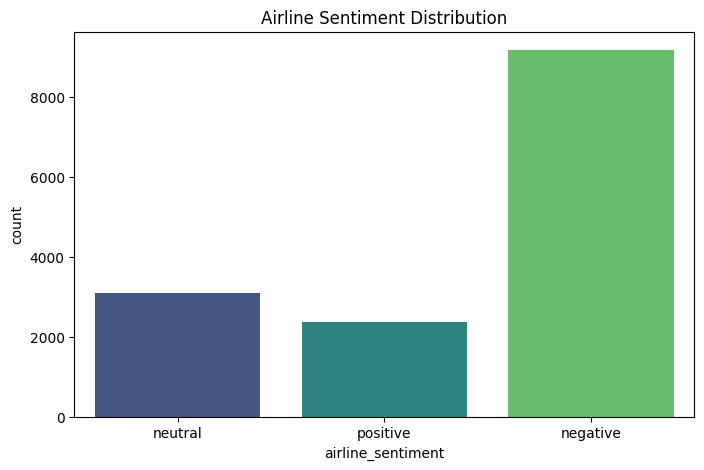


Calculated Class Weights: {0: np.float64(0.5317062540858575), 1: np.float64(1.5747015166182639), 2: np.float64(2.0651713922979265)}


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 28s 121ms/step - accuracy: 0.5659 - loss: 0.9686 - val_accuracy: 0.6519 - val_loss: 0.7599
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.7608 - loss: 0.6397 - val_accuracy: 0.7662 - val_loss: 0.5668
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.8380 - loss: 0.4493 - val_accuracy: 0.7722 - val_loss: 0.5788
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.8832 - loss: 0.3221 - val_accuracy: 0.7765 - val_loss: 0.6200
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.9153 - loss: 0.2473 - val_accuracy: 0.7534 - val_loss: 0.7138
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

FINAL EVALUATION
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86      1835
     neutral       0.60      0.69      0.65       620
    positive       0.69      0.73      0.71       473

    accuracy                           0.79    

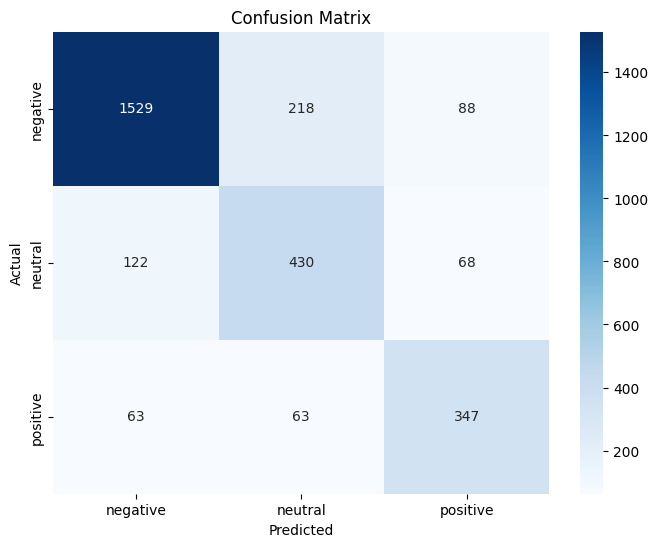

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, GRU, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# STEP 1: LOAD AND ANALYZE DATA
# ==========================================
df = pd.read_csv('tweets.csv')

print("Sentiment Counts:")
print(df['airline_sentiment'].value_counts())

# Visualize Class Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='airline_sentiment', data=df, palette='viridis')
plt.title('Airline Sentiment Distribution')
plt.show()

# ==========================================
# STEP 2: PREPROCESSING (Added Stopword Removal)
# ==========================================
# Common words that don't carry heavy sentiment weight
STOPWORDS = set(["a", "an", "the", "and", "it", "for", "or", "but", "in", "my", "your", "our", "is", "at", "on"])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)                # Remove mentions (@unitied, etc)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)            # Remove punctuation/numbers
    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in STOPWORDS])
    return text.strip()

df['cleaned_text'] = df['text'].apply(clean_text)

# Encoding labels (negative: 0, neutral: 1, positive: 2)
le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])
num_classes = len(le.classes_)

# Calculate Class Weights to handle the high number of negative tweets
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights_dict = {i: weights[i] for i in range(len(weights))}
print(f"\nCalculated Class Weights: {class_weights_dict}")

# ==========================================
# STEP 3: TOKENIZATION
# ==========================================
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=max_len)

# Use stratify=y to ensure train/test sets have same sentiment proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# STEP 4: MODEL ARCHITECTURE (Improved)
# ==========================================
def build_hybrid_model(rnn_type='lstm'):
    model = Sequential([
        # input_length removed (Future-proofed)
        Embedding(max_words, 128),
        SpatialDropout1D(0.3),

        # CNN layer to extract local features
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(4),

        # Bidirectional RNN to capture context from both directions
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)) if rnn_type == 'lstm'
        else Bidirectional(GRU(64, dropout=0.2, recurrent_dropout=0.2)),

        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize the model
model = build_hybrid_model(rnn_type='lstm')
model.summary()

# ==========================================
# STEP 5: TRAINING WITH CLASS WEIGHTS
# ==========================================
# restore_best_weights=True ensures we keep the best version of the model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights_dict, # Applying the balance fix here
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# STEP 6: EVALUATION
# ==========================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*30)
print("FINAL EVALUATION")
print("="*30)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()